In [1]:
from numpy import *
import ROOT
import os, sys, time
from array import array
import numpy as np
import ROOT
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad
from scipy.interpolate import interp1d
import pynucastro as pyna
from matplotlib.ticker import MultipleLocator, LogLocator

In [6]:
"""

data_file = ROOT.TFile("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260414_c13d_01/FILTERED/DataF_CH2@N6724B_214_20260414_c13d_01.root")
data_file.ls()
tree = data_file.Get("Data_F")
tree.Print()

"""

In [13]:
ch_2 = ROOT.TChain("Data_F")

In [21]:
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260413_c13d_15/FILTERED/DataF_CH2@N6724B_214_20260413_c13d_15.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260413_c13d_16/FILTERED/DataF_CH2@N6724B_214_20260413_c13d_16.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260413_c13d_17/FILTERED/DataF_CH2@N6724B_214_20260413_c13d_17.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260413_c13d_18/FILTERED/DataF_CH2@N6724B_214_20260413_c13d_18.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260414_c13d_01/FILTERED/DataF_CH2@N6724B_214_20260414_c13d_01.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260414_c13d_02/FILTERED/DataF_CH2@N6724B_214_20260414_c13d_02.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260414_c13d_03/FILTERED/DataF_CH2@N6724B_214_20260414_c13d_03.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260414_c13d_04/FILTERED/DataF_CH2@N6724B_214_20260414_c13d_04.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260414_c13d_05/FILTERED/DataF_CH2@N6724B_214_20260414_c13d_05.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260414_c13d_06/FILTERED/DataF_CH2@N6724B_214_20260414_c13d_06.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260414_c13d_07/FILTERED/DataF_CH2@N6724B_214_20260414_c13d_07.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260414_c13d_08/FILTERED/DataF_CH2@N6724B_214_20260414_c13d_08.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260414_c13d_09/FILTERED/DataF_CH2@N6724B_214_20260414_c13d_09.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260414_c13d_10/FILTERED/DataF_CH2@N6724B_214_20260414_c13d_10.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260414_c13d_11/FILTERED/DataF_CH2@N6724B_214_20260414_c13d_11.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260414_c13d_12/FILTERED/DataF_CH2@N6724B_214_20260414_c13d_12.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260414_c13d_13/FILTERED/DataF_CH2@N6724B_214_20260414_c13d_13.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260414_c13d_14/FILTERED/DataF_CH2@N6724B_214_20260414_c13d_14.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260414_c13d_15/FILTERED/DataF_CH2@N6724B_214_20260414_c13d_15.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260414_c13d_16/FILTERED/DataF_CH2@N6724B_214_20260414_c13d_16.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260414_c13d_17/FILTERED/DataF_CH2@N6724B_214_20260414_c13d_17.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260414_c13d_18/FILTERED/DataF_CH2@N6724B_214_20260414_c13d_18.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260414_c13d_19/FILTERED/DataF_CH2@N6724B_214_20260414_c13d_19.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260414_c13d_20/FILTERED/DataF_CH2@N6724B_214_20260414_c13d_20.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260415_c13d_01/FILTERED/DataF_CH2@N6724B_214_20260415_c13d_01.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260415_c13d_02/FILTERED/DataF_CH2@N6724B_214_20260415_c13d_02.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260415_c13d_03/FILTERED/DataF_CH2@N6724B_214_20260415_c13d_03.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260415_c13d_04/FILTERED/DataF_CH2@N6724B_214_20260415_c13d_04.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260415_c13d_05/FILTERED/DataF_CH2@N6724B_214_20260415_c13d_05.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260415_c13d_07/FILTERED/DataF_CH2@N6724B_214_20260415_c13d_07.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260415_c13d_08/FILTERED/DataF_CH2@N6724B_214_20260415_c13d_08.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260415_c13d_09/FILTERED/DataF_CH2@N6724B_214_20260415_c13d_09.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260415_c13d_10/FILTERED/DataF_CH2@N6724B_214_20260415_c13d_10.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260415_c13d_11/FILTERED/DataF_CH2@N6724B_214_20260415_c13d_11.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260415_c13d_12/FILTERED/DataF_CH2@N6724B_214_20260415_c13d_12.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260415_c13d_13/FILTERED/DataF_CH2@N6724B_214_20260415_c13d_13.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260415_c13d_14/FILTERED/DataF_CH2@N6724B_214_20260415_c13d_14.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260415_c13d_15/FILTERED/DataF_CH2@N6724B_214_20260415_c13d_15.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260415_c13d_16/FILTERED/DataF_CH2@N6724B_214_20260415_c13d_16.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260415_c13d_17/FILTERED/DataF_CH2@N6724B_214_20260415_c13d_17.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260415_c13d_18/FILTERED/DataF_CH2@N6724B_214_20260415_c13d_18.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260415_c13d_19/FILTERED/DataF_CH2@N6724B_214_20260415_c13d_19.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260415_c13d_20/FILTERED/DataF_CH2@N6724B_214_20260415_c13d_20.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260415_c13d_21/FILTERED/DataF_CH2@N6724B_214_20260415_c13d_21.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260415_c13d_22/FILTERED/DataF_CH2@N6724B_214_20260415_c13d_22.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260415_c13d_23/FILTERED/DataF_CH2@N6724B_214_20260415_c13d_23.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260416_c13d_01/FILTERED/DataF_CH2@N6724B_214_20260416_c13d_01.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260416_c13d_02/FILTERED/DataF_CH2@N6724B_214_20260416_c13d_02.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260416_c13d_03/FILTERED/DataF_CH2@N6724B_214_20260416_c13d_03.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260416_c13d_04/FILTERED/DataF_CH2@N6724B_214_20260416_c13d_04.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260416_c13d_05/FILTERED/DataF_CH2@N6724B_214_20260416_c13d_05.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260416_c13d_06/FILTERED/DataF_CH2@N6724B_214_20260416_c13d_06.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260416_c13d_07/FILTERED/DataF_CH2@N6724B_214_20260416_c13d_07.root")
ch_2.Add("/Users/shahina/Documents/MIT/d+13C_exp_LEIA/13CD_cross_section_data/13CD_cross_section_20260413/DAQ/20260416_c13d_08/FILTERED/DataF_CH2@N6724B_214_20260416_c13d_08.root")





















1

In [22]:
# Combined data from all root files 
calib_all_1 = np.array([event.CalibEnergy for event in ch_2])

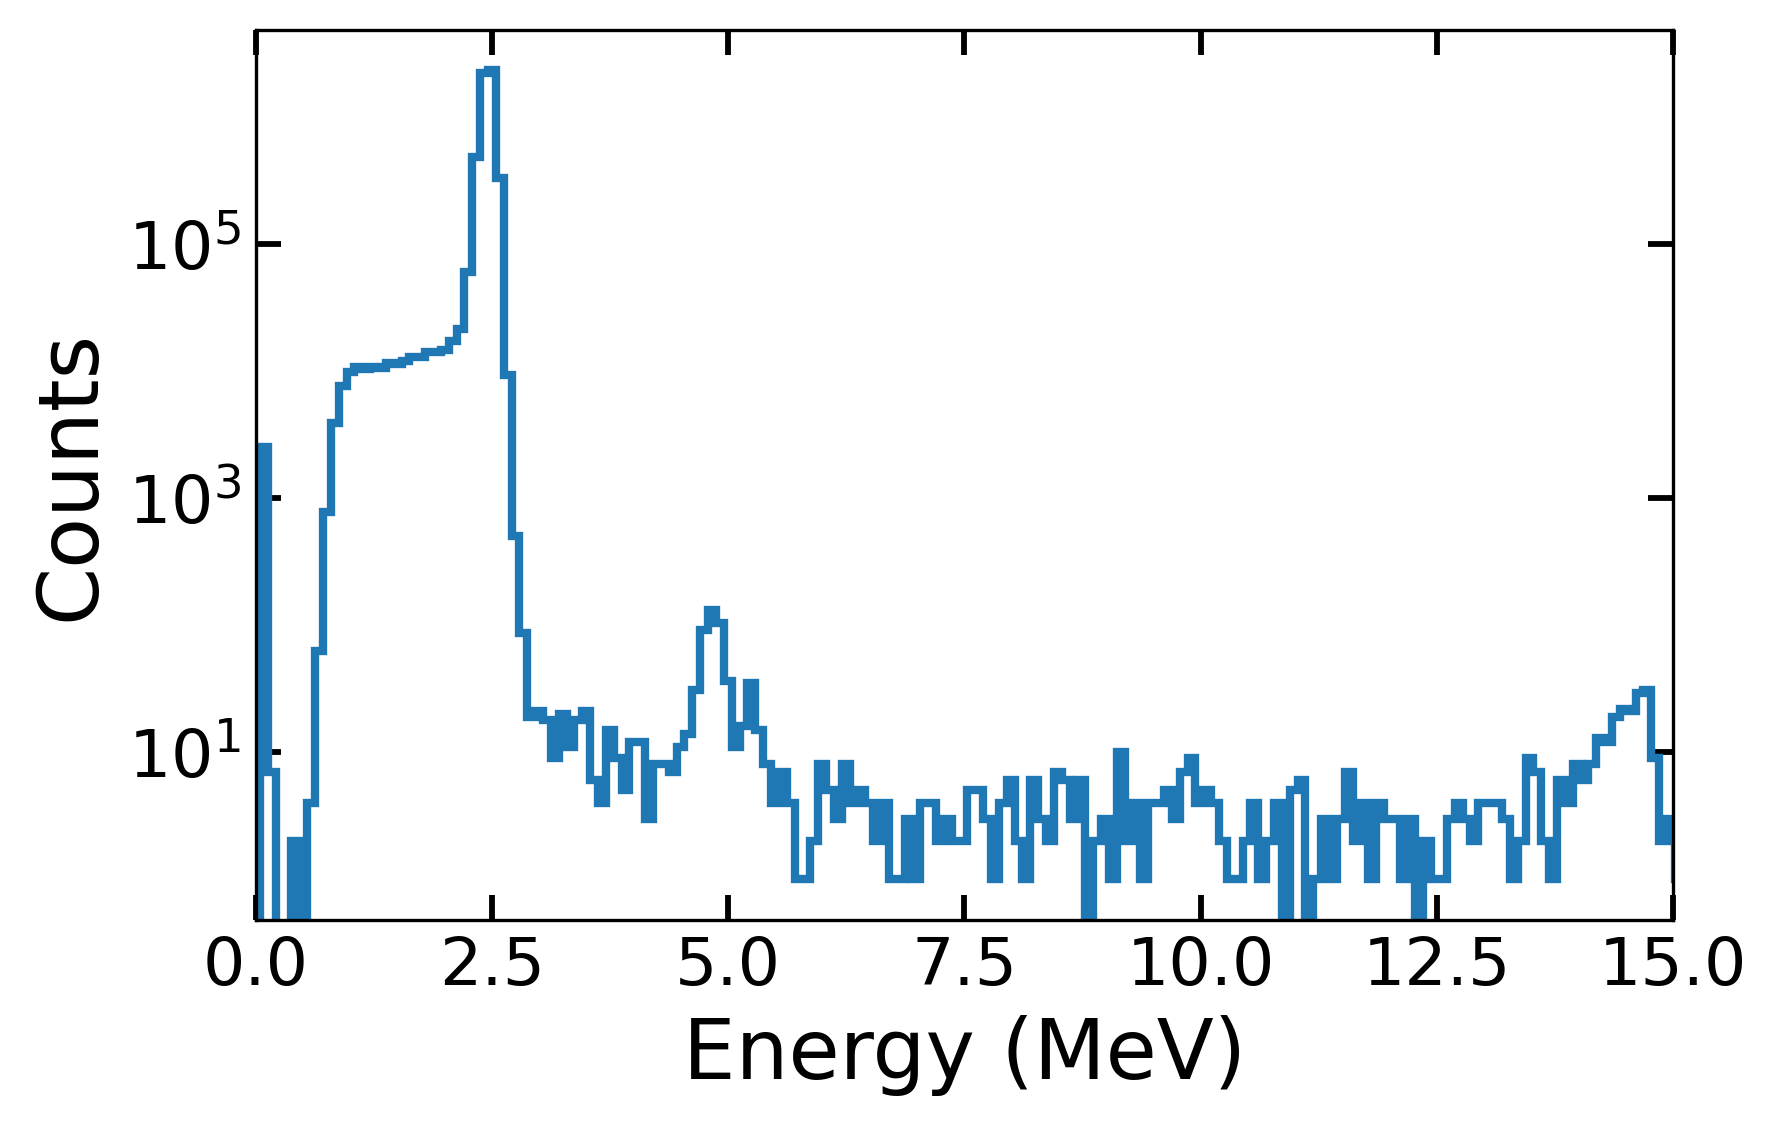

In [53]:
plt.figure(figsize=(6,4),dpi=300)


# Ticks
plt.tick_params(which="both", direction="in", top=True, right=True,
                labelsize=16, length=6, width=1.4)
plt.gca().yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0,10.0)*0.1, numticks=10))
plt.hist(calib_all_1, bins=500, histtype='step',linewidth=2)

plt.xlabel("Energy (MeV)",fontsize = 20)
plt.ylabel("Counts",fontsize = 20)
plt.xlim(0,15)
plt.tick_params(axis='both', labelsize=16)
plt.tight_layout()
#plt.xscale("log")
plt.yscale("log")
plt.show()

Fit: μ = 4.8370 MeV,  σ = 0.0944 MeV
Peak counts = 357.1 ± 29.5


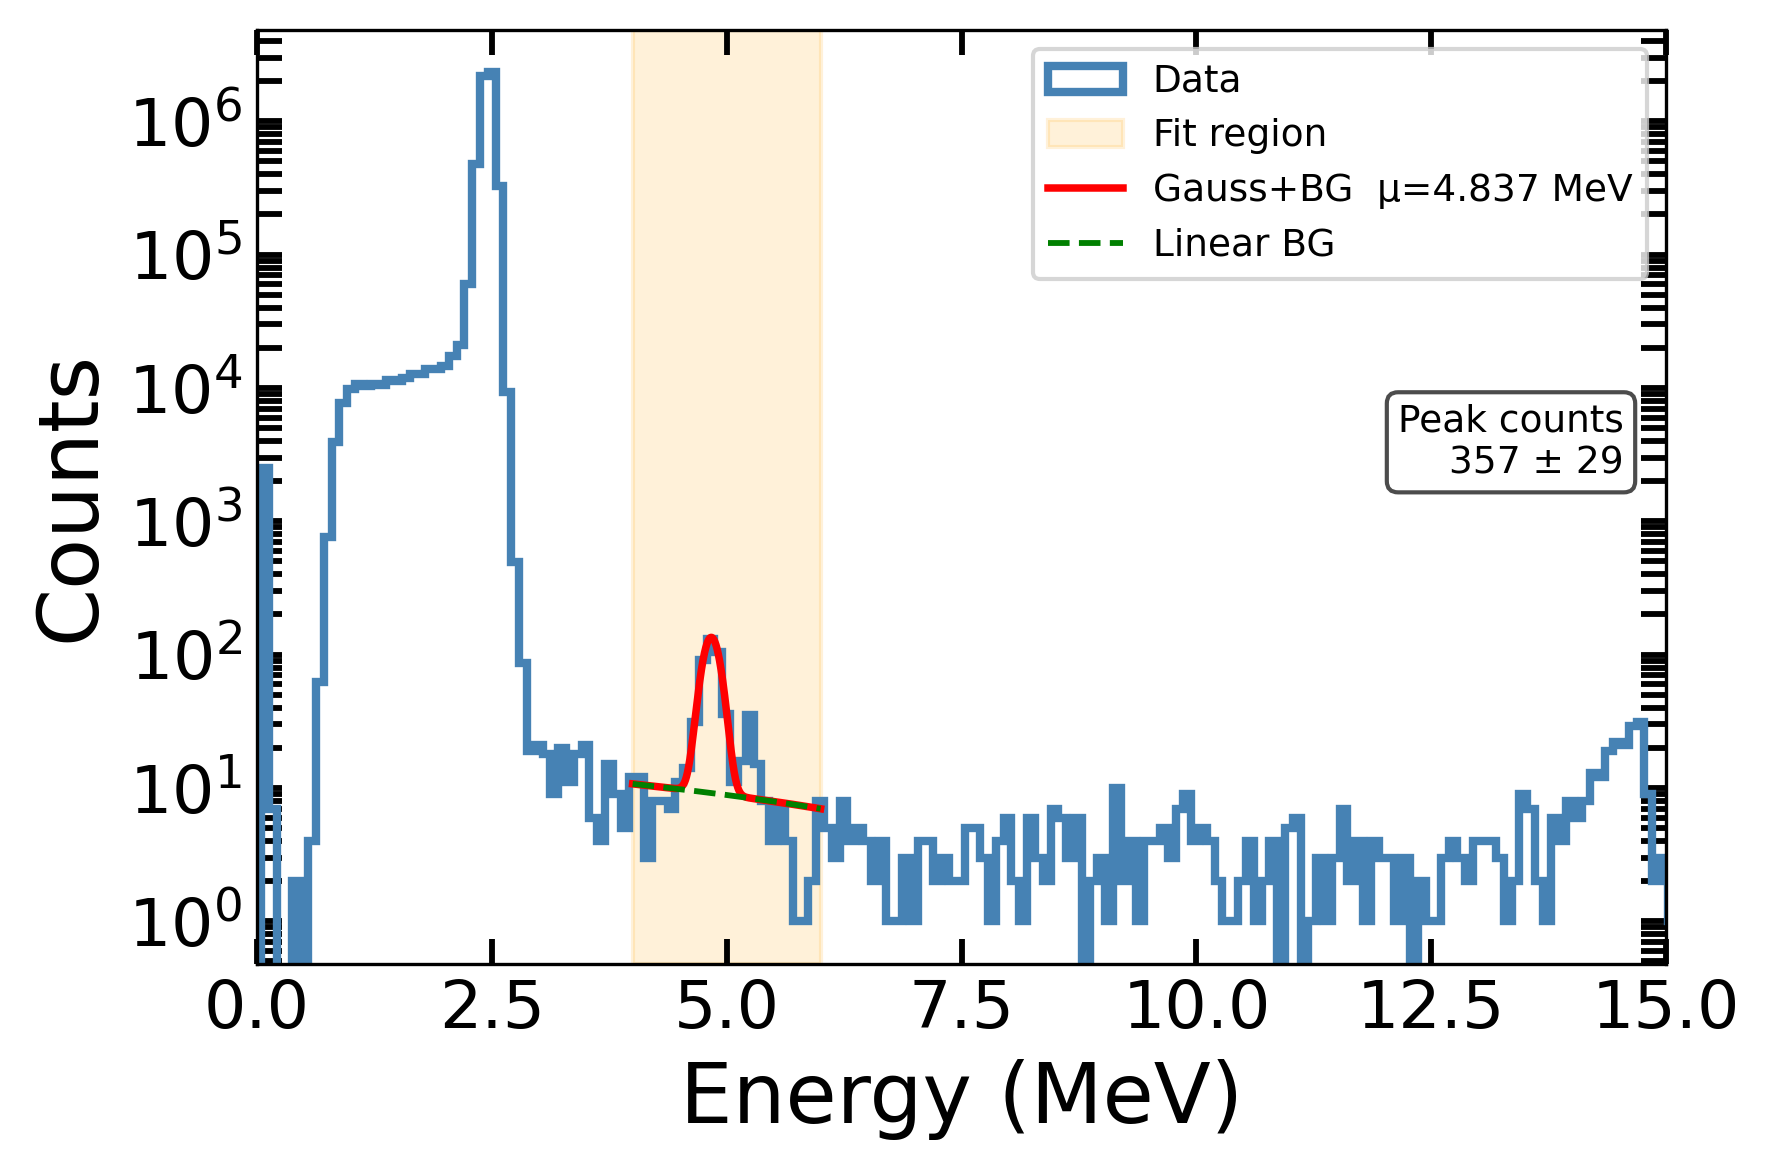

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import LogLocator
from scipy.optimize import curve_fit
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# --- Model: Gaussian + linear background ---
def gauss_linear(x, A, mu, sigma, m, b):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2) + m * x + b

# --- Histogram the data ---
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

counts, bin_edges, _ = ax.hist(
    calib_all_1, bins=500, histtype='step', linewidth=2, color='steelblue', label='Data'
)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# --- Define fit region around 5 MeV ---
fit_lo, fit_hi = 4.0, 6.0          # ← adjust as needed
mask = (bin_centers >= fit_lo) & (bin_centers <= fit_hi)
x_fit = bin_centers[mask]
y_fit = counts[mask]

# --- Initial guesses ---
p0 = [y_fit.max(), 5.0, 0.2,        # A, mu, sigma
      0.0, y_fit.min()]               # m, b

popt, pcov = curve_fit(gauss_linear, x_fit, y_fit, p0=p0, maxfev=10000)
perr = np.sqrt(np.diag(pcov))
A, mu, sigma, m, b = popt

# --- Counts under peak (Gaussian area / bin width) ---
bin_width = bin_edges[1] - bin_edges[0]
peak_counts = A * np.abs(sigma) * np.sqrt(2 * np.pi) / bin_width
peak_counts_err = peak_counts * np.sqrt((perr[0]/A)**2 + (perr[2]/sigma)**2)

print(f"Fit: μ = {mu:.4f} MeV,  σ = {sigma:.4f} MeV")
print(f"Peak counts = {peak_counts:.1f} ± {peak_counts_err:.1f}")

# --- Highlight fitted region ---
x_dense = np.linspace(fit_lo, fit_hi, 1000)
y_model  = gauss_linear(x_dense, *popt)
y_bg     = m * x_dense + b

ax.axvspan(fit_lo, fit_hi, alpha=0.15, color='orange', label='Fit region')
ax.plot(x_dense, y_model, 'r-',  linewidth=1.8, label=f'Gauss+BG  μ={mu:.3f} MeV')
ax.plot(x_dense, y_bg,    'g--', linewidth=1.4, label='Linear BG')

# --- Main axes formatting ---
ax.set_xlabel("Energy (MeV)", fontsize=20)
ax.set_ylabel("Counts", fontsize=20)
ax.set_xlim(0, 15)
ax.set_yscale("log")
ax.tick_params(which="both", direction="in", top=True, right=True,
               labelsize=16, length=6, width=1.4)
ax.yaxis.set_minor_locator(
    LogLocator(base=10.0, subs=np.arange(1.0, 10.0) * 0.1, numticks=10)
)
ax.legend(fontsize=9, loc='upper right')

# Add peak-count annotation
ax.text(0.97, 0.60,
        f"Peak counts\n{peak_counts:.0f} ± {peak_counts_err:.0f}",
        transform=ax.transAxes, fontsize=9,
        ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))



plt.tight_layout()
plt.show()

In [ ]:
357/(0.172)

μ = 4.8370 MeV,  σ = 0.0944 MeV
Peak counts = 357.1 ± 29.5


/var/folders/w2/q902ycmx685fl8gdqjlb8qbw0000gp/T/ipykernel_29625/3305653326.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


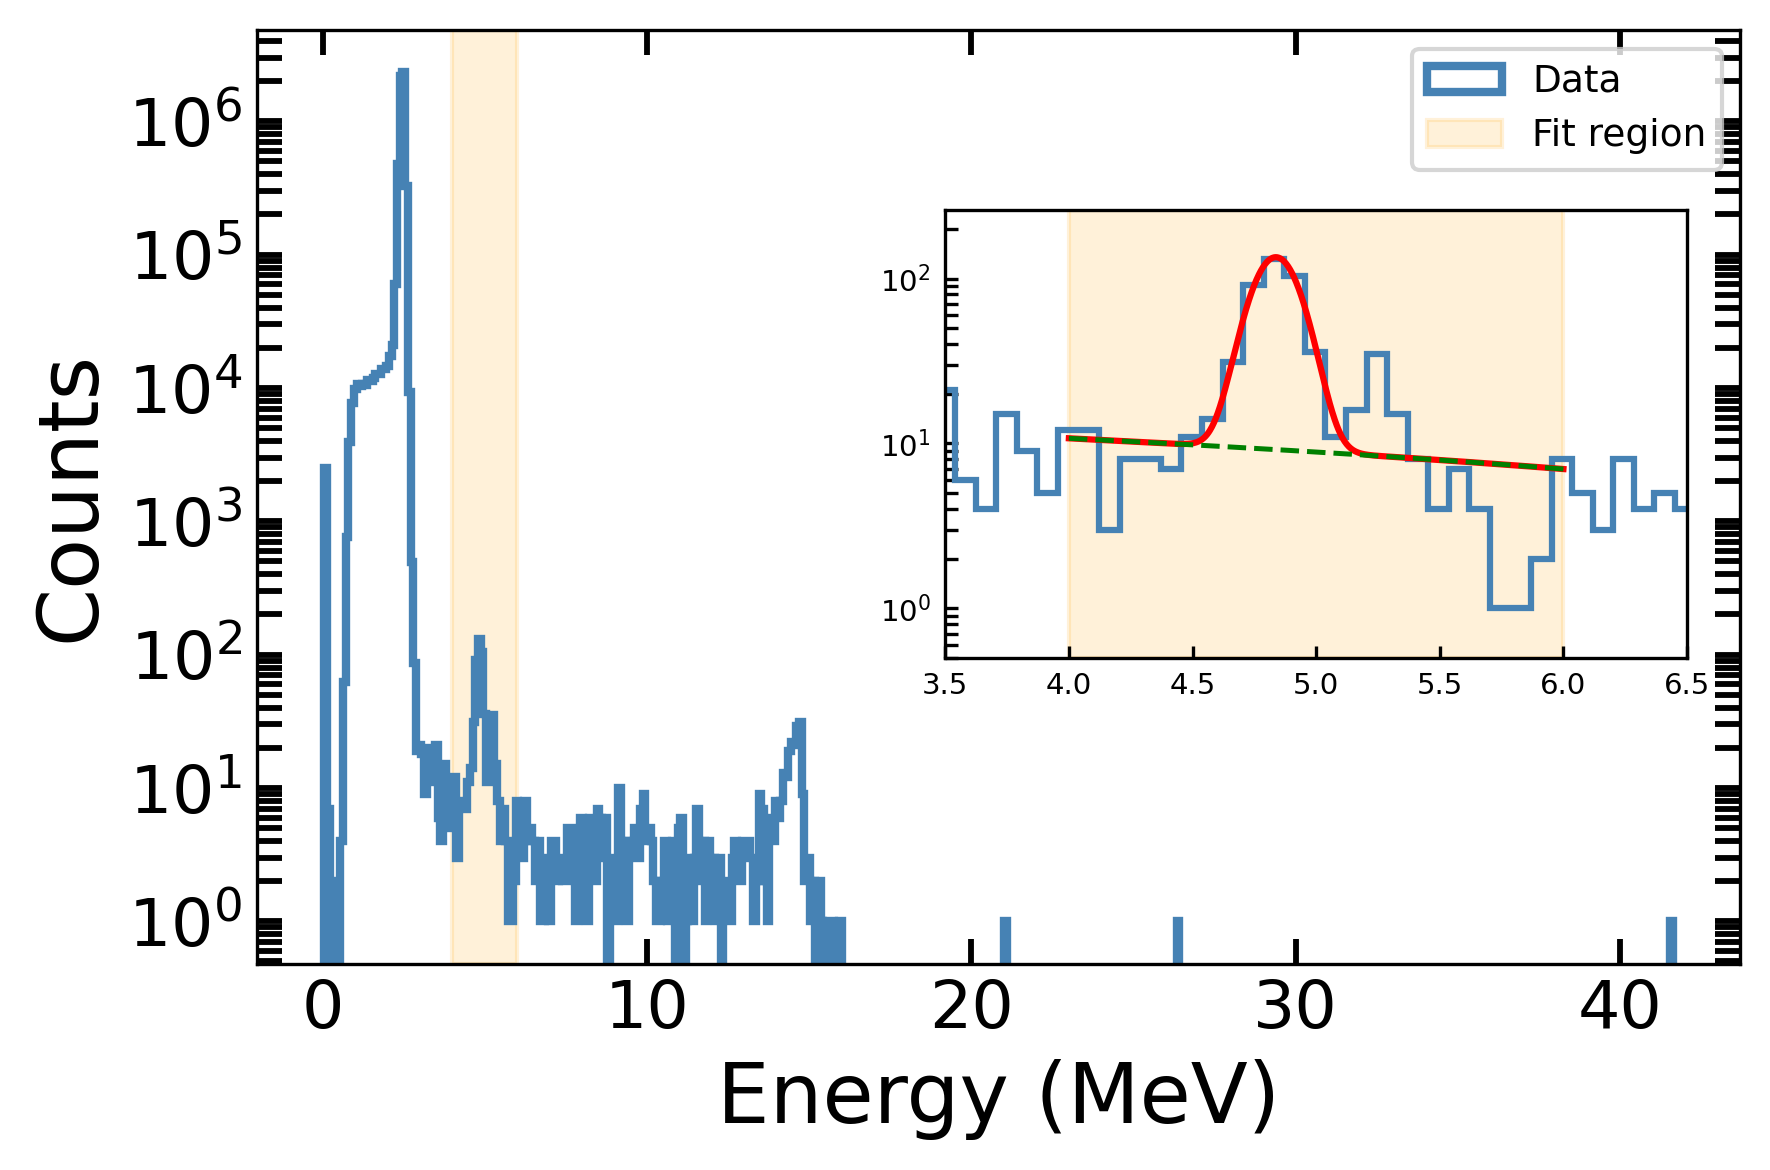

In [109]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator
from scipy.optimize import curve_fit
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import FancyArrowPatch

def gauss_linear(x, A, mu, sigma, m, b):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2) + m * x + b

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

counts, bin_edges, _ = ax.hist(
    calib_all_1, bins=500, histtype='step', linewidth=2, color='steelblue', label='Data'
)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

fit_lo, fit_hi = 4.0, 6.0
mask = (bin_centers >= fit_lo) & (bin_centers <= fit_hi)
x_fit, y_fit = bin_centers[mask], counts[mask]

p0 = [y_fit.max(), 5.0, 0.2, 0.0, y_fit.min()]
popt, pcov = curve_fit(gauss_linear, x_fit, y_fit, p0=p0, maxfev=10000)
perr = np.sqrt(np.diag(pcov))
A, mu, sigma, m, b = popt

bin_width = bin_edges[1] - bin_edges[0]
peak_counts     = A * np.abs(sigma) * np.sqrt(2 * np.pi) / bin_width
peak_counts_err = peak_counts * np.sqrt((perr[0]/A)**2 + (perr[2]/sigma)**2)
print(f"μ = {mu:.4f} MeV,  σ = {sigma:.4f} MeV")
print(f"Peak counts = {peak_counts:.1f} ± {peak_counts_err:.1f}")

x_dense = np.linspace(fit_lo, fit_hi, 1000)
y_model = gauss_linear(x_dense, *popt)
y_bg    = m * x_dense + b

# Main axes
ax.axvspan(fit_lo, fit_hi, alpha=0.15, color='orange', label='Fit region')
ax.set_xlabel("Energy (MeV)", fontsize=20)
ax.set_ylabel("Counts", fontsize=20)
#ax.set_xlim(0, 15)
ax.set_yscale("log")
ax.tick_params(which="both", direction="in", top=True, right=True,
               labelsize=16, length=6, width=1.4)
ax.yaxis.set_minor_locator(
    LogLocator(base=10.0, subs=np.arange(1.0, 10.0) * 0.1, numticks=10)
)
ax.legend(fontsize=9, loc='upper right')



# ── Inset: bigger, just below legend ────────────────────────────────────────
ax_inset = inset_axes(ax, width="100%", height="100%",
                      bbox_to_anchor=(0.45, 0.35, 0.5, 0.48),
                      bbox_transform=ax.transAxes,
                      loc='upper left')

ax_inset.hist(calib_all_1, bins=500, histtype='step', linewidth=1.5, color='steelblue')
ax_inset.axvspan(fit_lo, fit_hi, alpha=0.15, color='orange')
ax_inset.plot(x_dense, y_model, 'r-',  linewidth=1.5, label=f'μ={mu:.3f} MeV')
ax_inset.plot(x_dense, y_bg,    'g--', linewidth=1.2, label='Linear BG')
ax_inset.set_xlim(fit_lo - 0.5, fit_hi + 0.5)

zoom_mask = (bin_centers >= fit_lo - 0.5) & (bin_centers <= fit_hi + 0.5)
y_zoom = counts[zoom_mask]
y_zoom_pos = y_zoom[y_zoom > 0]
if len(y_zoom_pos):
    ax_inset.set_ylim(y_zoom_pos.min() * 0.5, y_zoom.max() * 2.0)

ax_inset.set_yscale("log")
ax_inset.tick_params(which="both", direction="in", labelsize=7, length=3, width=0.8)
ax_inset.set_xlabel("")
ax_inset.set_ylabel("")
#ax_inset.legend(fontsize=7)

# ── Arrows from the top edge of the orange region to the inset corners ───────
# We use figure-level coords via transFigure for cross-axes arrows.
# First, get the y-top of the highlighted span in data coords → display → figure

fig.canvas.draw()  # needed to finalise transforms before reading positions



plt.tight_layout()
plt.show()

Peak 1 — μ = 4.8370 MeV,  σ = 0.0944 MeV,  counts = 357.1 ± 29.5
Peak 2 — μ = 2.4601 MeV,  σ = 0.0632 MeV,  counts = 5323132.0 ± 185059.1


/var/folders/w2/q902ycmx685fl8gdqjlb8qbw0000gp/T/ipykernel_29625/3731231041.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


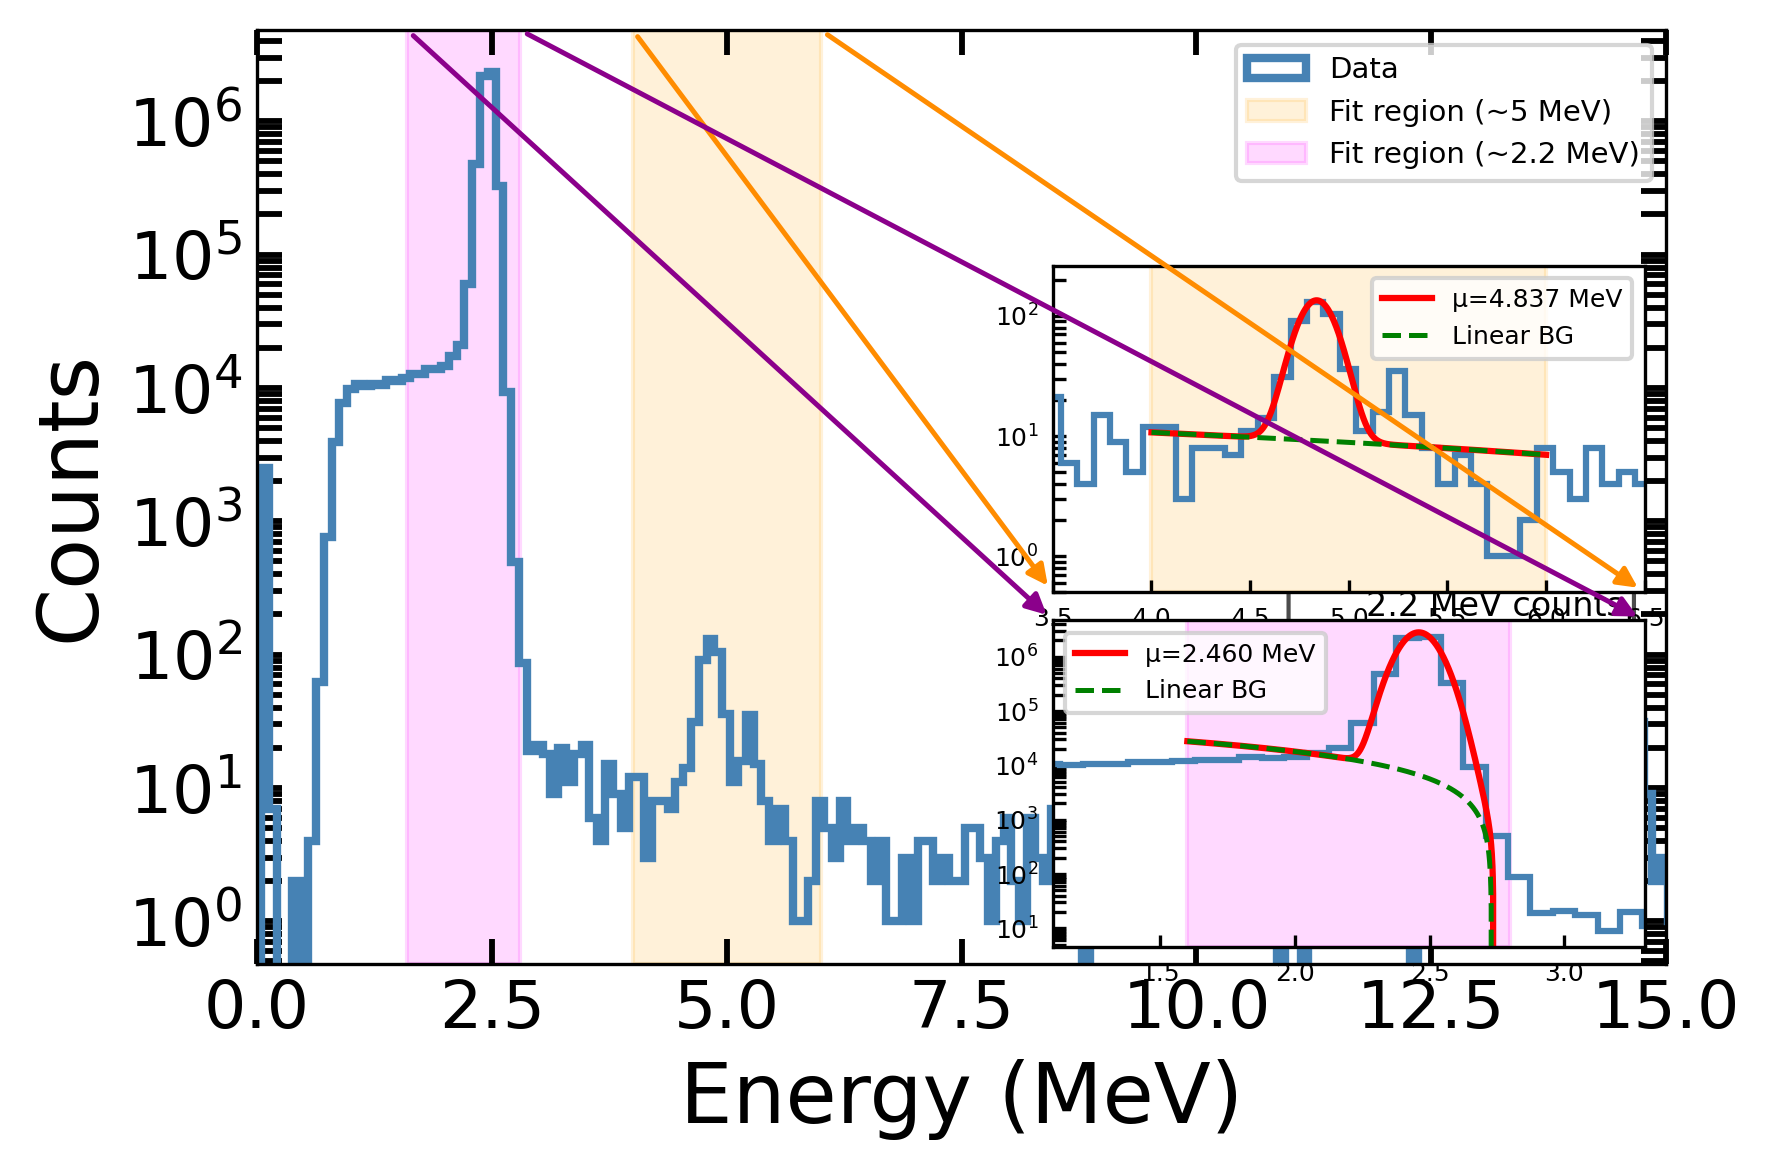

In [84]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator
from scipy.optimize import curve_fit
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import FancyArrowPatch

def gauss_linear(x, A, mu, sigma, m, b):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2) + m * x + b

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

counts, bin_edges, _ = ax.hist(
    calib_all_1, bins=500, histtype='step', linewidth=2, color='steelblue', label='Data'
)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_width = bin_edges[1] - bin_edges[0]

# ── Helper ───────────────────────────────────────────────────────────────────
def fit_peak(bin_centers, counts, fit_lo, fit_hi, p0):
    mask = (bin_centers >= fit_lo) & (bin_centers <= fit_hi)
    x_fit, y_fit = bin_centers[mask], counts[mask]
    popt, pcov = curve_fit(gauss_linear, x_fit, y_fit, p0=p0, maxfev=10000)
    perr = np.sqrt(np.diag(pcov))
    A, mu, sigma, m, b = popt
    peak_counts     = A * np.abs(sigma) * np.sqrt(2 * np.pi) / bin_width
    peak_counts_err = peak_counts * np.sqrt((perr[0]/A)**2 + (perr[2]/sigma)**2)
    return popt, perr, peak_counts, peak_counts_err

def data_to_fig(ax, fig, x, y):
    disp = ax.transData.transform((x, y))
    return fig.transFigure.inverted().transform(disp)

# ── Fit 1: ~5 MeV ────────────────────────────────────────────────────────────
fit_lo1, fit_hi1 = 4.0, 6.0
popt1, perr1, pc1, pc1_err = fit_peak(
    bin_centers, counts, fit_lo1, fit_hi1,
    p0=[counts[(bin_centers >= fit_lo1) & (bin_centers <= fit_hi1)].max(), 5.0, 0.2, 0.0,
        counts[(bin_centers >= fit_lo1) & (bin_centers <= fit_hi1)].min()]
)
A1, mu1, sigma1, m1, b1 = popt1
x_dense1 = np.linspace(fit_lo1, fit_hi1, 1000)
y_model1  = gauss_linear(x_dense1, *popt1)
y_bg1     = m1 * x_dense1 + b1
print(f"Peak 1 — μ = {mu1:.4f} MeV,  σ = {sigma1:.4f} MeV,  counts = {pc1:.1f} ± {pc1_err:.1f}")

# ── Fit 2: ~2.2 MeV ──────────────────────────────────────────────────────────
fit_lo2, fit_hi2 = 1.6, 2.8
popt2, perr2, pc2, pc2_err = fit_peak(
    bin_centers, counts, fit_lo2, fit_hi2,
    p0=[counts[(bin_centers >= fit_lo2) & (bin_centers <= fit_hi2)].max(), 2.2, 0.2, 0.0,
        counts[(bin_centers >= fit_lo2) & (bin_centers <= fit_hi2)].min()]
)
A2, mu2, sigma2, m2, b2 = popt2
x_dense2 = np.linspace(fit_lo2, fit_hi2, 1000)
y_model2  = gauss_linear(x_dense2, *popt2)
y_bg2     = m2 * x_dense2 + b2
print(f"Peak 2 — μ = {mu2:.4f} MeV,  σ = {sigma2:.4f} MeV,  counts = {pc2:.1f} ± {pc2_err:.1f}")

# ── Main axes ────────────────────────────────────────────────────────────────
ax.axvspan(fit_lo1, fit_hi1, alpha=0.15, color='orange',  label='Fit region (~5 MeV)')
ax.axvspan(fit_lo2, fit_hi2, alpha=0.15, color='magenta', label='Fit region (~2.2 MeV)')

ax.set_xlabel("Energy (MeV)", fontsize=20)
ax.set_ylabel("Counts", fontsize=20)
ax.set_xlim(0, 15)
ax.set_yscale("log")
ax.tick_params(which="both", direction="in", top=True, right=True,
               labelsize=16, length=6, width=1.4)
ax.yaxis.set_minor_locator(
    LogLocator(base=10.0, subs=np.arange(1.0, 10.0) * 0.1, numticks=10)
)
ax.legend(fontsize=7, loc='upper right')

# Peak count annotations
ax.text(0.97, 0.55,
        f"5 MeV counts\n{pc1:.0f} ± {pc1_err:.0f}",
        transform=ax.transAxes, fontsize=8, ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

ax.text(0.97, 0.40,
        f"2.2 MeV counts\n{pc2:.0f} ± {pc2_err:.0f}",
        transform=ax.transAxes, fontsize=8, ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

# ── Inset 1: ~5 MeV  (upper right, below legend) ────────────────────────────
ax_inset1 = inset_axes(ax, width="100%", height="100%",
                        bbox_to_anchor=(0.55, 0.42, 0.42, 0.35),
                        bbox_transform=ax.transAxes, loc='upper left')

ax_inset1.hist(calib_all_1, bins=500, histtype='step', linewidth=1.5, color='steelblue')
ax_inset1.axvspan(fit_lo1, fit_hi1, alpha=0.15, color='orange')
ax_inset1.plot(x_dense1, y_model1, 'r-',  linewidth=1.5, label=f'μ={mu1:.3f} MeV')
ax_inset1.plot(x_dense1, y_bg1,    'g--', linewidth=1.2, label='Linear BG')
ax_inset1.set_xlim(fit_lo1 - 0.5, fit_hi1 + 0.5)

zm1 = (bin_centers >= fit_lo1 - 0.5) & (bin_centers <= fit_hi1 + 0.5)
y_z1 = counts[zm1]; y_z1p = y_z1[y_z1 > 0]
if len(y_z1p):
    ax_inset1.set_ylim(y_z1p.min() * 0.5, y_z1.max() * 2.0)

ax_inset1.set_yscale("log")
ax_inset1.tick_params(which="both", direction="in", labelsize=6, length=3, width=0.8)
ax_inset1.set_xlabel(""); ax_inset1.set_ylabel("")
ax_inset1.legend(fontsize=6)

# ── Inset 2: ~2.2 MeV  (below inset 1) ──────────────────────────────────────
ax_inset2 = inset_axes(ax, width="100%", height="100%",
                        bbox_to_anchor=(0.55, 0.04, 0.42, 0.35),
                        bbox_transform=ax.transAxes, loc='upper left')

ax_inset2.hist(calib_all_1, bins=500, histtype='step', linewidth=1.5, color='steelblue')
ax_inset2.axvspan(fit_lo2, fit_hi2, alpha=0.15, color='magenta')
ax_inset2.plot(x_dense2, y_model2, 'r-',  linewidth=1.5, label=f'μ={mu2:.3f} MeV')
ax_inset2.plot(x_dense2, y_bg2,    'g--', linewidth=1.2, label='Linear BG')
ax_inset2.set_xlim(fit_lo2 - 0.5, fit_hi2 + 0.5)

zm2 = (bin_centers >= fit_lo2 - 0.5) & (bin_centers <= fit_hi2 + 0.5)
y_z2 = counts[zm2]; y_z2p = y_z2[y_z2 > 0]
if len(y_z2p):
    ax_inset2.set_ylim(y_z2p.min() * 0.5, y_z2.max() * 2.0)

ax_inset2.set_yscale("log")
ax_inset2.tick_params(which="both", direction="in", labelsize=6, length=3, width=0.8)
ax_inset2.set_xlabel(""); ax_inset2.set_ylabel("")
ax_inset2.legend(fontsize=6)

# ── Arrows ───────────────────────────────────────────────────────────────────
plt.tight_layout()
fig.canvas.draw()

y_top = ax.get_ylim()[1]

arrow_props_orange  = dict(arrowstyle="-|>", color='darkorange',  lw=1.2,
                           mutation_scale=10, connectionstyle="arc3,rad=0.0")
arrow_props_magenta = dict(arrowstyle="-|>", color='darkmagenta', lw=1.2,
                           mutation_scale=10, connectionstyle="arc3,rad=0.0")

# Arrows for inset 1 (orange, ~5 MeV)
pos1 = ax_inset1.get_position()
for start, end in [
    (data_to_fig(ax, fig, fit_lo1, y_top), (pos1.x0, pos1.y0)),
    (data_to_fig(ax, fig, fit_hi1, y_top), (pos1.x1, pos1.y0)),
]:
    fig.add_artist(FancyArrowPatch(posA=start, posB=end,
                                   transform=fig.transFigure, **arrow_props_orange))

# Arrows for inset 2 (magenta, ~2.2 MeV)
pos2 = ax_inset2.get_position()
for start, end in [
    (data_to_fig(ax, fig, fit_lo2, y_top), (pos2.x0, pos2.y1)),
    (data_to_fig(ax, fig, fit_hi2, y_top), (pos2.x1, pos2.y1)),
]:
    fig.add_artist(FancyArrowPatch(posA=start, posB=end,
                                   transform=fig.transFigure, **arrow_props_magenta))

plt.show()

Peak 1 — μ = 4.8370 MeV,  σ = 0.0944 MeV,  counts = 357.1 ± 29.5
Peak 2 — μ = 2.4601 MeV,  σ = 0.0632 MeV,  counts = 5323132.0 ± 185059.1


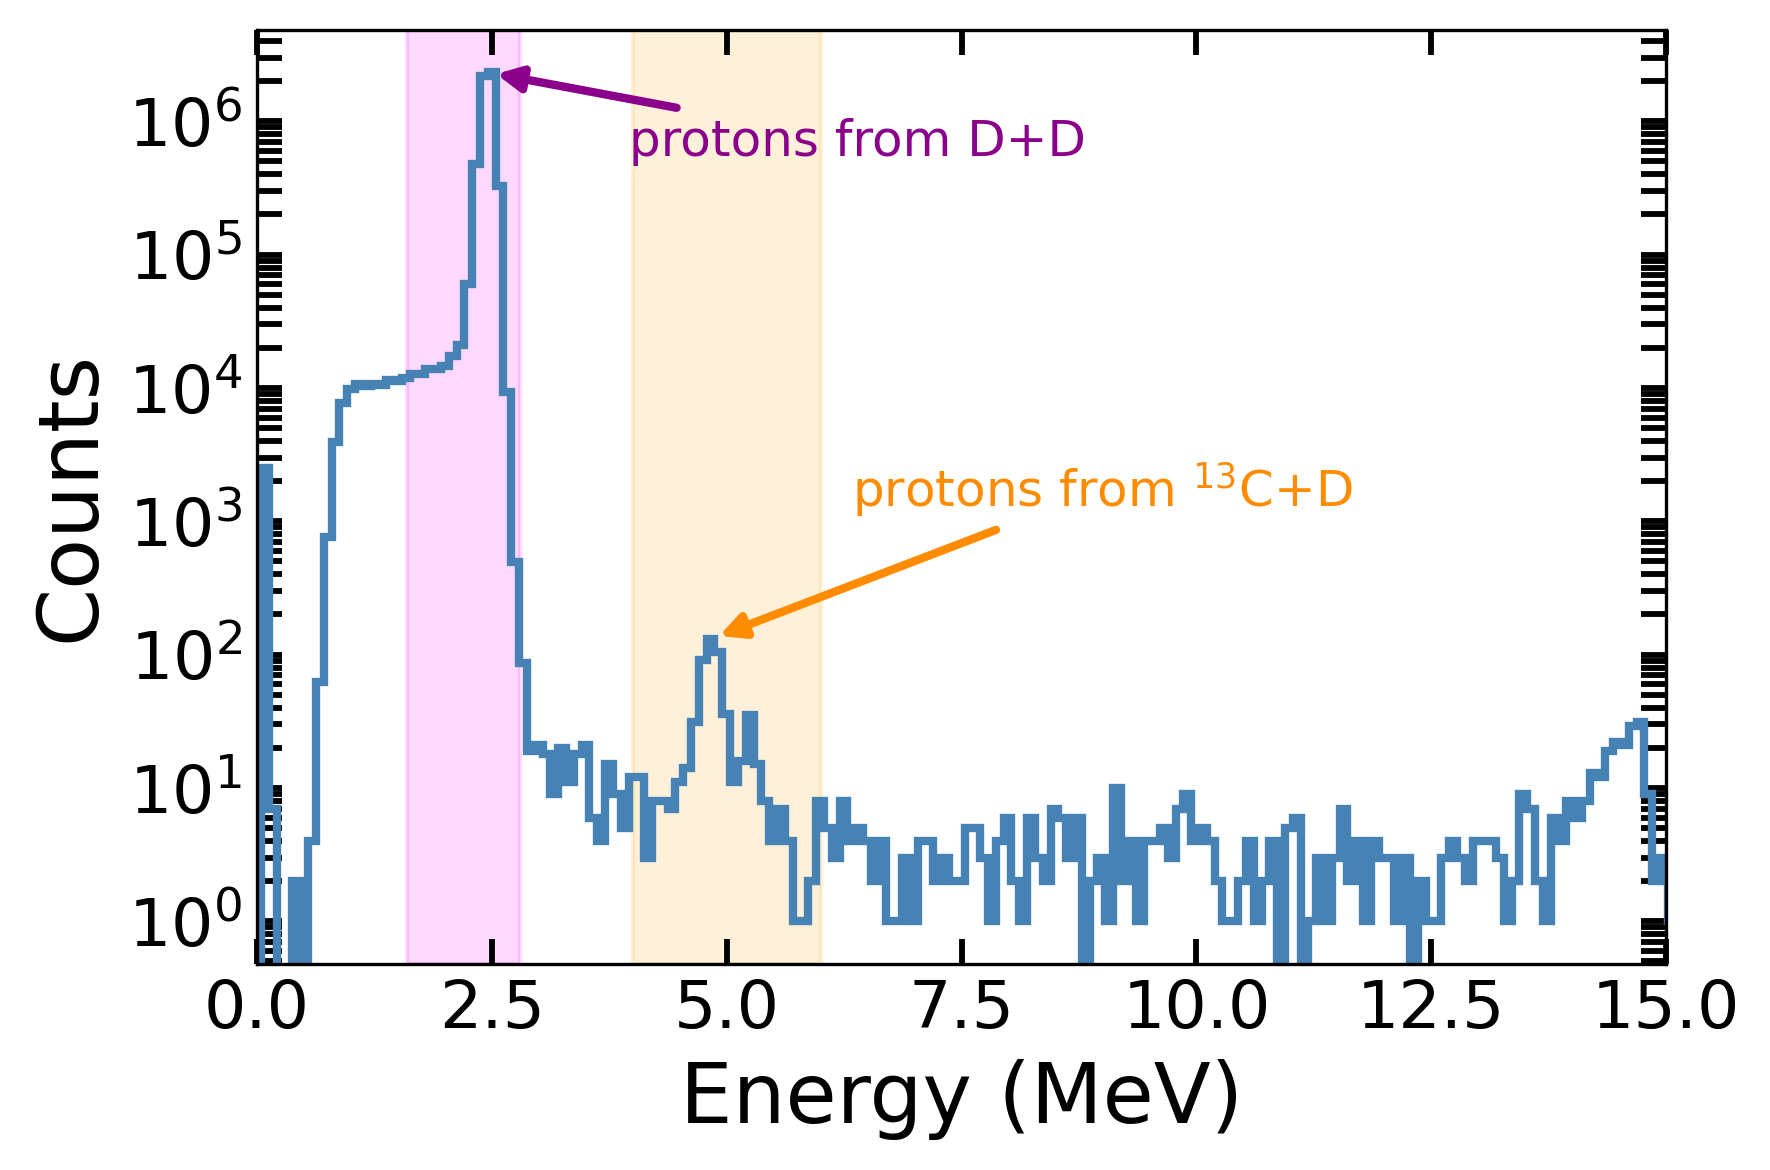

In [108]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator
from scipy.optimize import curve_fit

def gauss_linear(x, A, mu, sigma, m, b):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2) + m * x + b

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

counts, bin_edges, _ = ax.hist(
    calib_all_1, bins=500, histtype='step', linewidth=2, color='steelblue', label='Data'
)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_width = bin_edges[1] - bin_edges[0]

def fit_peak(bin_centers, counts, fit_lo, fit_hi, p0):
    mask = (bin_centers >= fit_lo) & (bin_centers <= fit_hi)
    x_fit, y_fit = bin_centers[mask], counts[mask]
    popt, pcov = curve_fit(gauss_linear, x_fit, y_fit, p0=p0, maxfev=10000)
    perr = np.sqrt(np.diag(pcov))
    A, mu, sigma, m, b = popt
    peak_counts     = A * np.abs(sigma) * np.sqrt(2 * np.pi) / bin_width
    peak_counts_err = peak_counts * np.sqrt((perr[0]/A)**2 + (perr[2]/sigma)**2)
    return popt, perr, peak_counts, peak_counts_err

# ── Fit 1: ~5 MeV ────────────────────────────────────────────────────────────
fit_lo1, fit_hi1 = 4.0, 6.0
mask1 = (bin_centers >= fit_lo1) & (bin_centers <= fit_hi1)
popt1, perr1, pc1, pc1_err = fit_peak(
    bin_centers, counts, fit_lo1, fit_hi1,
    p0=[counts[mask1].max(), 5.0, 0.2, 0.0, counts[mask1].min()]
)
A1, mu1, sigma1, m1, b1 = popt1
print(f"Peak 1 — μ = {mu1:.4f} MeV,  σ = {sigma1:.4f} MeV,  counts = {pc1:.1f} ± {pc1_err:.1f}")

# ── Fit 2: ~2.2 MeV ──────────────────────────────────────────────────────────
fit_lo2, fit_hi2 = 1.6, 2.8
mask2 = (bin_centers >= fit_lo2) & (bin_centers <= fit_hi2)
popt2, perr2, pc2, pc2_err = fit_peak(
    bin_centers, counts, fit_lo2, fit_hi2,
    p0=[counts[mask2].max(), 2.2, 0.2, 0.0, counts[mask2].min()]
)
A2, mu2, sigma2, m2, b2 = popt2
print(f"Peak 2 — μ = {mu2:.4f} MeV,  σ = {sigma2:.4f} MeV,  counts = {pc2:.1f} ± {pc2_err:.1f}")

# ── Main axes ────────────────────────────────────────────────────────────────
ax.axvspan(fit_lo1, fit_hi1, alpha=0.15, color='orange')
ax.axvspan(fit_lo2, fit_hi2, alpha=0.15, color='magenta')

ax.set_xlabel("Energy (MeV)", fontsize=20)
ax.set_ylabel("Counts", fontsize=20)
ax.set_xlim(0, 15)
ax.set_yscale("log")
ax.tick_params(which="both", direction="in", top=True, right=True,
               labelsize=16, length=6, width=1.4)
ax.yaxis.set_minor_locator(
    LogLocator(base=10.0, subs=np.arange(1.0, 10.0) * 0.1, numticks=10)
)

# ── Simple text + straight arrows ────────────────────────────────────────────
y_tip1 = counts[(bin_centers >= mu1 - 0.05) & (bin_centers <= mu1 + 0.05)].max()
y_tip2 = counts[(bin_centers >= mu2 - 0.05) & (bin_centers <= mu2 + 0.05)].max()

# 2.2 MeV — text above and to the right, straight arrow down to peak
ax.annotate(
    "protons from D+D",
    xy=(mu2, y_tip2),
    xytext=(mu2 + 1.5, y_tip2 * 0.2),      # ← adjust x/y offset to taste
    fontsize=12,
    ha='left', va='bottom',
    color='darkmagenta',
    arrowprops=dict(arrowstyle="-|>", color='darkmagenta', lw=2,
                    connectionstyle="arc3,rad=0.0")   # rad=0 → straight line
)

# 5 MeV — text above and to the right, straight arrow down to peak
ax.annotate(
    "protons from $^{13}$C+D",
    xy=(mu1, y_tip1),
    xytext=(mu1 + 1.5, y_tip1 * 8),      # ← adjust x/y offset to taste
    fontsize=12,
    ha='left', va='bottom',
    color='darkorange',
    arrowprops=dict(arrowstyle="-|>", color='darkorange', lw=2,
                    connectionstyle="arc3,rad=0.0")
)

plt.tight_layout()
plt.show()

In [86]:
counts_13CD = np.sum((calib_all_1 > 4.0) & (calib_all_1 < 5.))

In [89]:
counts_13CD

np.int64(557)

In [90]:
counts_DD = np.sum((calib_all_1 > 0.7) & (calib_all_1 < 3))

In [91]:
counts_DD

np.int64(5601279)

In [92]:
cross_DD = 20.56 #barns # But this is angle integrated 
differential_cross_DD = 20.56/(4*np.pi)

In [93]:
differential_cross_13CD = (counts_13CD/counts_DD)* (differential_cross_DD)

In [94]:
differential_cross_13CD

np.float64(0.00016269763351307246)

In [ ]:
357/0.172